<a href="https://colab.research.google.com/github/leejunho12316/HonGongMachine/blob/main/%EB%A9%80%ED%8B%B0%EB%AA%A8%EB%8B%AC_RAG_%EC%8B%A4%EC%A0%84%EB%AC%B8%EC%A0%9C_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#환경설정

데이터 다운로드

In [3]:
!wget https://arxiv.org/pdf/2403.10131.pdf

--2026-03-10 01:54:25--  https://arxiv.org/pdf/2403.10131.pdf
Resolving arxiv.org (arxiv.org)... 151.101.67.42, 151.101.3.42, 151.101.131.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.67.42|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /pdf/2403.10131 [following]
--2026-03-10 01:54:25--  https://arxiv.org/pdf/2403.10131
Reusing existing connection to arxiv.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 784351 (766K) [application/pdf]
Saving to: ‘2403.10131.pdf’

2403.10131.pdf      100%[===================>] 765.97K  --.-KB/s    in 0.03s   

2026-03-10 01:54:25 (24.2 MB/s) - ‘2403.10131.pdf’ saved [784351/784351]



Unstructured 세팅

In [4]:
%%capture --no-stderr
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev
!sudo apt-get install poppler-utils

In [5]:
%%capture --no-stderr
!pip install -U "unstructured[all-docs]" lxml pillow==9.5.0 pdf2image==1.16.3 layoutparser[layoutmodels,tesseract]==0.3.4

In [6]:
import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

#데이터 정제

##1. Unstructured로 요소 추출
Unstructured 패키지로 테이터 추출

In [1]:
import os
import base64
from PIL import Image
from IPython.display import display, HTML
from unstructured.partition.pdf import partition_pdf

In [2]:
# 파일 경로 설정
image_path = '/content/fig'
file_name = "2403.10131.pdf"

# PDF에서 요소 추출
raw_pdf_elements = partition_pdf(
    filename=file_name,
    extract_images_in_pdf=True, # 이미지 추출
    skip_infer_table_types=False, # False로 하면 테이블을 추출
    chunking_strategy="by_title", # 텍스트를 섹션 경계에 따라서 청킹
    max_characters=2000, # 각 청킹 별 최대 글자 수
    new_after_n_chars=2000, # 이 숫자를 넘으면 추가로 잘라라
    combine_text_under_n_chars=2000, # 이 크기 이하의 텍스트는 다른 텍스트와 결합하라
    extract_image_block_output_dir=image_path,
)

yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

text, table 추출

In [3]:
tables = []
texts = []

for chunk in raw_pdf_elements:
    if "CompositeElement" in str(type(chunk)):  # Check if it's a CompositeElement
        for element in chunk.metadata.orig_elements:  # Iterate through its elements
            if "Table" in str(type(element)):  # Now check for Table type
                tables.append(element)  # Append the table element
        texts.append(chunk)  # Still append the CompositeElement to texts

image 추출 (작은 이미지 삭제)

In [35]:
import os
from PIL import Image

# 이미지 디렉토리 경로 (원래대로 복원)
image_path = "/content/fig"  # ← 이 줄이 핵심입니다. 당신 환경에 맞게 경로 수정하십시오.

# 1. 조건에 맞는 모든 파일 저장할 리스트
all_files = []

# 2. width 50 이하인 파일 저장할 리스트
small_width_files = []

# 3. height 50 이하인 파일 저장할 리스트
small_height_files = []

# 디렉토리 내 파일 순회
for filename in os.listdir(image_path):
    # 파일명이 'figure'로 시작하고 '.jpg'로 끝나는지 확인
    if filename.startswith('figure') and filename.endswith('.jpg'):
        all_files.append(filename)  # all_files에 추가
        try:
            # 이미지 열기
            with Image.open(os.path.join(image_path, filename)) as img:
                width, height = img.size
                # width가 50 이하인 경우 small_width_files에 추가
                if width <= 50:
                    small_width_files.append(filename)
                # height가 50 이하인 경우 small_height_files에 추가
                if height <= 50:
                    small_height_files.append(filename)
        except Exception as e:
            print(f"파일 열기 실패: {filename}, 에러: {e}")

# 문자열 기준 정렬
all_files = sorted(all_files)
small_width_files = sorted(small_width_files)
small_height_files = sorted(small_height_files)
large_width_files = sorted(list(set(all_files) - set(small_width_files)))

# 결과 출력
print(f"모든 'figure*.jpg' 파일 ({len(all_files)}개):")
print(all_files)

print(f"\n가로 50 이하인 파일 ({len(small_width_files)}개):")
print(small_width_files)

print(f"\n세로 50 이하인 파일 ({len(small_height_files)}개):")
print(small_height_files)

모든 'figure*.jpg' 파일 (6개):
['figure-2-1.jpg', 'figure-2-2.jpg', 'figure-2-3.jpg', 'figure-3-4.jpg', 'figure-8-5.jpg', 'figure-9-6.jpg']

가로 50 이하인 파일 (0개):
[]

세로 50 이하인 파일 (0개):
[]


In [36]:
# 이제 small_width_files 파일들을 삭제하는 코드
for filename in small_width_files:
    file_path = os.path.join(image_path, filename)
    try:
        os.remove(file_path)
        print(f"삭제 완료: {filename}")
    except Exception as e:
        print(f"삭제 실패: {filename}, 에러: {e}")

출력해보기


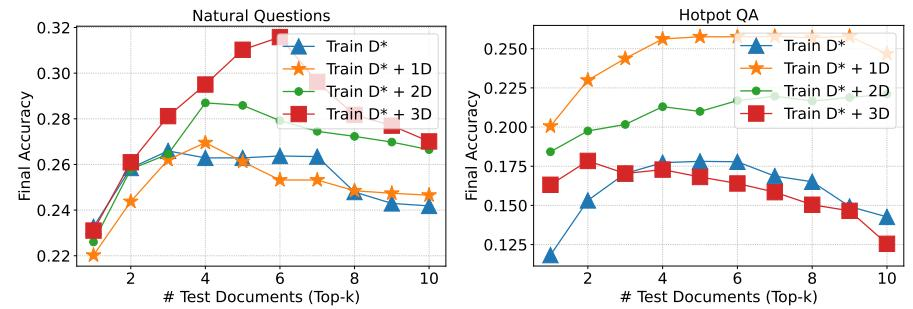

In [34]:
file_path = '/content/fig/figure-9-6.jpg'

html = "<div style='display: flex; flex-wrap: wrap;'>"
with open(file_path, "rb") as img_file:
    b64_img = base64.b64encode(img_file.read()).decode('utf-8')
    html += f"""
    <div style="flex: none; max-width: 200px; margin-right: 10px; margin-bottom: 10px;">
        <img src="data:image/jpeg;base64,{b64_img}" style="width: 100%; height: auto; display: block; object-fit: contain;">
    </div>
    """
html += "</div>"

display(HTML(html))

##2. LLM QA 합성 데이터

pdf 이미지로부터 LLM으로 텍스트 추출. 참고 데이터로 pdf로부터 텍스트 추출 후 같이 입력.
LLM으로 QA 합성 데이터 생성.

pdf에서 이미지 추출

In [37]:
!pip install pymupdf openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 66.0 MB/s eta 0:00:00


In [40]:
import io
import fitz
from PIL import Image
import numpy as np

In [41]:
# 이미지를 base64 형식으로 인코딩하는 함수
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [42]:
# PNG 이미지를 최적화하는 함수
def optimize_png(img):
    img_buffer = io.BytesIO()
    img.save(img_buffer, format='PNG', optimize=True, compress_level=6)
    optimized_img = Image.open(img_buffer)
    return optimized_img

# PDF 파일을 처리하여 각 페이지를 이미지로 저장하는 함수
def process_pdf(pdf_path, output_folder, dpi=300):
    doc = fitz.open(pdf_path)
    os.makedirs(output_folder, exist_ok=True)

    for page_num in range(len(doc)):
        page = doc[page_num]
        zoom = dpi / 72
        mat = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat, alpha=False)

        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        img_array = np.array(img)

        # 이미지 최적화 후 저장
        optimize_png(img).save(os.path.join(output_folder, f'page_{page_num+1}.png'))

    doc.close()

In [43]:
# 사용 예시: PDF 파일을 이미지로 변환
pdf_path = '/content/2403.10131.pdf'
output_folder = '.'
process_pdf(pdf_path, output_folder)

pdf에서 텍스트 추출

In [44]:
import os
import re
import fitz  # PyMuPDF

def pdf_to_page_txts(pdf_path: str, output_dir: str = "pages") -> None:
    os.makedirs(output_dir, exist_ok=True)                # 출력 폴더 준비
    with fitz.open(pdf_path) as doc:
        total_pages = doc.page_count                      # 닫히기 전에 미리 저장
        for idx, page in enumerate(doc, start=1):
            text = page.get_text()                        # 텍스트 추출
            filename = f"page_{idx}.txt"
            filepath = os.path.join(output_dir, filename)
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text)
    print(f"{total_pages}개 페이지를 {output_dir} 폴더에 저장했습니다.")

In [45]:
pdf_file = "/content/2403.10131.pdf"
pdf_to_page_txts(pdf_file, ".")

12개 페이지를 . 폴더에 저장했습니다.


이미지-텍스트 매칭

In [46]:
# 디렉토리에서 매칭되는 TXT과 PNG 파일들을 가져오는 함수
def get_matched_files(directory):
    files = os.listdir(directory)

    xml_files = {}
    png_files = {}

    # TXT과 PNG 파일들을 분류
    for file in files:
        match = re.match(r'page_(\d+)\.(txt|png)$', file)
        if match:
            number = int(match.group(1))
            extension = match.group(2)
            if extension == 'txt':
                xml_files[number] = file
            elif extension == 'png':
                png_files[number] = file

    # 모든 페이지 번호를 결합하여 매칭
    all_numbers = set(xml_files.keys()).union(set(png_files.keys()))

    matched_files = []
    for number in sorted(all_numbers):
        xml_path = os.path.join(directory, xml_files[number]) if number in xml_files else 'no txt'
        png_path = os.path.join(directory, png_files[number]) if number in png_files else 'no png'
        matched_files.append((xml_path, png_path))

    return matched_files

In [47]:
# 사용 예시: 매칭된 파일 가져오기
directory = r'/content'
files = get_matched_files(directory)

In [48]:
files

[('/content/page_1.txt', '/content/page_1.png'),
 ('/content/page_2.txt', '/content/page_2.png'),
 ('/content/page_3.txt', '/content/page_3.png'),
 ('/content/page_4.txt', '/content/page_4.png'),
 ('/content/page_5.txt', '/content/page_5.png'),
 ('/content/page_6.txt', '/content/page_6.png'),
 ('/content/page_7.txt', '/content/page_7.png'),
 ('/content/page_8.txt', '/content/page_8.png'),
 ('/content/page_9.txt', '/content/page_9.png'),
 ('/content/page_10.txt', '/content/page_10.png'),
 ('/content/page_11.txt', '/content/page_11.png'),
 ('/content/page_12.txt', '/content/page_12.png')]

GPT로 이미지 텍스트 추출

In [50]:
from tqdm import tqdm
import base64
import openai

In [51]:
os.environ["OPENAI_API_KEY"] = ""

In [52]:
client = openai.OpenAI()

In [53]:
# TXT이 없는 경우 사용할 시스템 프롬프트
no_txt_system_prompt = '''당신이 해석할 이미지는 리포트입니다.
1. 중요한 내용이므로 요약하지말고 문법에 신경쓰면서 보이는 그대로 작성해주세요.
2. 내용을 임의로 바꾸지 마세요. 그리고 보이는 모든 내용을 다 적으십시오.
3. 단, 테이블은 풀어서 평문 또는 나열식으로 작성해주세요. 이미지에 없는 말은 적지마세요.
4. 테이블 풀어서 평문 또는 나열식으로 작성할 때 다른 행과 열이랑 헷갈리지 않게 값마다 잘 구분해서 적어주세요.
5. 테이블 해석할 때 통합셀들이 존재하니 구조를 잘 해석해서 작성해주시기 바랍니다. 어떤 게 어떤 것의 하위 내용인지를 명확히 하십시오
6. 당신의 의견은 궁금하지 않습니다. 해드렸습니다. 완성했습니다. 이런 표현도 적지마십시오. 이미지에 있는 내용만 적으십시오.
7. 만약 다단으로 구성되어져 있다면 좌측 테이블부터 먼저 작성하고 우측 테이블을 작성하십시오.
8. 수식은 반드시 마크다운으로 전부 다 작성하십시오. 가장 중요한 지시사항입니다.

자, 당신이 모든 내용을 빠트리지 않으면서 테이블은 구조를 잘 해석해서 작성해주는 것을 믿습니다.
'''

In [54]:
# TXT가 있는 경우 사용할 시스템 프롬프트
system_prompt = '''당신이 해석할 이미지는 리포트입니다.
1. 중요한 내용이므로 요약하지말고 문법에 신경쓰면서 보이는 그대로 작성해주세요.
2. 내용을 임의로 바꾸지 마세요. 그리고 보이는 모든 내용을 다 적으십시오.
3. 단, 테이블은 풀어서 평문 또는 나열식으로 작성해주세요. 이미지에 없는 말은 적지마세요.
4. 테이블 풀어서 평문 또는 나열식으로 작성할 때 다른 행과 열이랑 헷갈리지 않게 값마다 잘 구분해서 적어주세요.
5. 테이블 해석할 때 통합셀들이 존재하니 구조를 잘 해석해서 작성해주시기 바랍니다. 어떤 게 어떤 것의 하위 내용인지를 명확히 하십시오
6. 당신의 의견은 궁금하지 않습니다. 해드렸습니다. 완성했습니다. 이런 표현도 적지마십시오. 이미지에 있는 내용만 적으십시오.
7. 만약 다단으로 구성되어져 있다면 좌측 테이블부터 먼저 작성하고 우측 테이블을 작성하십시오.
8. 수식은 반드시 마크다운으로 전부 다 작성하십시오. 가장 중요한 지시사항입니다.
9. 당신에게 당신이 해석할 파일을 txt로 변경한 내용도 드리겠습니다. 페이지 해석할 때 참고하세요.
10. txt에 있는 텍스트는 반드시 해당 페이지에 존재한다는 겁니다. txt에 있는 텍스트를 빠트리지 마십시오.

자 당신이 헷갈리지 않도록 txt도 드렸습니다. 이미지를 더 잘 해석할 거라 믿습니다.
'''

In [55]:
%%time
# 이미지와 txt 파일을 사용하여 AI 모델에 요청을 보내는 코드
result_lst = []
for file in tqdm(files):
    image_path = file[1]

    # 이미지를 base64 형식으로 인코딩
    base64_image = encode_image(image_path)

    if file[0] == 'no txt':
        print(file[1], '은 txt가 없습니다.')
        prompt = no_txt_system_prompt
    else:
        with open(file[0], 'r', encoding='utf-8') as f:
            xml_content = f.read()
        prompt = system_prompt + xml_content + '\n시작!'

    response = client.chat.completions.create(
    model="gpt-4.1",
    max_tokens=2500,
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{base64_image}"}},
                {"type": "text", "text": prompt}
            ]
        }
    ]
    )
    result_lst.append(response.choices[0].message.content)

100%|██████████| 12/12 [02:02<00:00, 10.20s/it]

CPU times: user 798 ms, sys: 77.3 ms, total: 876 ms
Wall time: 2min 2s


In [58]:
print(result_lst[0])

Preprint, Under Review

RAFT: Adapting Language Model to Domain Specific RAG

Tianjun Zhang  
Department of Computer Science  
UC Berkeley  
Berkeley, CA 94720, USA  
{tianjunz}@berkeley.edu  

Shishir G. Patil, Naman Jain, Sheng Shen  
Department of Computer Science  
UC Berkeley  
Berkeley, CA 94720, USA  
{shishirpatil, naman_jain, sheng.s}@berkeley.edu  

Matei Zaharia, Ion Stoica, Joseph E. Gonzalez  
Department of Computer Science  
UC Berkeley  
Berkeley, CA 94720, USA  
{matei, istoica, jegonzal}@berkeley.edu  

Abstract

Pretraining Large Language Models (LLMs) on large corpora of textual data is now a standard paradigm. When using these LLMs for many downstream applications, it is common to additionally incorporate new information into the pretrained model either through RAG-based-prompting, or finetuning. However, the best methodology to incorporate information remains an open question. In this paper, we present Retrieval Augmented Fine Tuning (RAFT), a training recipe which

In [59]:
# 결과를 페이지와 연결하여 저장
result = []
for f, r in zip(files, result_lst):
    result.append({'content': r, 'source': 'page_' + f[1].split('page_')[1]})

QA 합성 데이터 제작

In [67]:
import os
import json
from tqdm import tqdm

In [68]:
file_path = 'results.jsonl'

system = '''당신은 주어진 2개의 문서로부터 사용자의 가능한 질문과 답변의 쌍 5개를 생성해야 합니다.

1. 2개의 문서는 서로 이어지는 문서이므로 문맥이 순차적으로 이어지고 있음을 감안하세요.
2. content는 본문이고 source는 출처입니다.
3. 주어진 2개의 문서로부터 가능한 질문과 답변의 쌍을 5개 생성하세요.
4. Q1과 A1, Q2와 A2, Q3과 A3, Q4과 A4, Q5과 A5 이렇게 작성하면됩니다.
5. 각 답변의 뒤에는 출처 문서들을 리스트 형태로 작성하세요. 다수의 문서를 동시에 참고할 수 있습니다.
6. 주어진 문서에 없는 내용은 작성하지 마십시오. 오직 'content' 안에 있는 내용만 답변할 수 있습니다.
7. 답변은 오직 'content' 안에 있는 내용으로만 답변하지만 최대한 풍부하고 길게 작성하세요. 이는 매우 중요합니다.
8. 다수의 문서를 동시에 참고하여 답변하는 것이 가능합니다.
9. 답변할 때 문서에 해당 항목이 약관의 몇 조인지 명확한 상황이라면 답변할 때 무조건 이를 언급하면 좋겠습니다. 제10조(보험금의 지급사유)에 따르면~ 이런 것처럼 몇 조인지 언급해서 답변해주시기 바랍니다. 이는 반드시 지켜져야 합니다.
10. 너무 억지스럽게 지엽적인 질문은 금지하겠습니다. 이것은 기계독해 문제가 아닙니다. 예를 들어 아래와 같은 질문은 지양하십시오.
ex) 보험금 지급에 관한 세부규정 중, 피보험자가 장해분류표 중 동일한 재해 또는 원인으로 여러 신체부위의 장해지급률을 더하여 50% 이상인 장해상태가 되었을 경우 보험료 납입 면제 조건은 무엇인가요?
11. 위와 같이 복잡한 질문이 아니라 일반 사용자가 할만한 질문을 던지십시오.
12. 주어진 문서에서 예시, 표, 마크다운 수식, 글머리 기호로 표시된 것들을 FAQ로 만드는 것을 주저하지 마십시오. 이들은 FAQ로 만들때 가장 먼저 우선순위를 가집니다. 이들이 가장 중요합니다.
13. 마크다운 수식 또한 중요하게 취급하여 답변에 포함하십시오.

예시)
입력: {'content': '약관 이용 가이드\n\n1. 보험약관이란?\n보험약관은 가입하신 보험계약의 내용 및 조건 등을 미리 정하여 놓은 계약조항으로 보험계약자와 보험회사의 권리 및 의무를 규정하고 있습니다.\n\n특히, 청약철회, 계약취소, 보험금 지급 및 지급제한 사항 등 보험계약의 중요사항에 대한 설명이 들어 있으니 반드시 확인하셔야 합니다.\n\n본 서류는 법령 및 금융소비자보호체계에 따른 절차를 거쳐 제공됩니다.\n\n2. 한 눈에 보는 약관의 구성\n약관 이용 가이드: 약관을 쉽게 잘 이용할 수 있도록 약관의 구성, 쉽게 찾는 방법 등의 내용을 담고 있는 지침서\n\n시각화된 약관 요약내용: 약관을 쉽게 잘 이용할 수 있도록 계약 주요내용 및 유의사항 등을 시각적 방법을 이용해 간단히 요약한 약관\n\n용어해설: 약관 이해를 돕기 위한 어려운 보험용어의 해설 등을 소비자에게 안내\n\n보험약관 (주계약&특약): \n- 주계약: 기본계약을 포함한 공통 사항을 정한 기본 약관\n- 특약: 주계약 외 선택 가입한 보장내용 등 필요한 사항을 정한 약관\n\n3. QR 코드를 통한 편리한 정보 이용\nQR(Quick Response) 코드란?\n스마트폰으로 해당 QR 코드를 스캔하면 상세내용 등을 손쉽게 안내받을 수 있습니다.\n\n약관해설 영상, 보험금정구시 구비서류, 회사소개 QR 코드가 제공되어 있습니다.', 'source': '약관_B00198011_1_P_page-0004.jpg'} {'content': '약관 이용 가이드\n\n4. 약관의 핵심 체크항목 쉽게 찾기\n\n보험약관 핵심사항 등과 관련된 해당 조문, 용어 및 영상자료(QR코드 스캔) 등을 안내드리오니, 보험회사로부터 약관을 수령한 후, 해당 내용을 반드시 확인·숙지 하시기 바랍니다.\n\n* QR(Quick Response)코드는 스마트폰으로 해당 QR 코드를 스캔하여 상세내용 등을 손쉽게 안내 받을 수 있습니다.\n\n보험금 지급 및 지급제한 사항: 제 10 조(보험금의 지급사유) P 18, 제 12 조(보험금을 지급하지 않는 사유) P 21, 영상자료\n\n주의! 본인이 가입한 특약을 확인하여 가입 특약별 "보험금 지급사유 및 미지급사유"도 반드시 확인이 필요함\n\n계약 전 알릴 의무 및 위반효과: 제 20 조(계약 전 알릴 의무 위반의 효과) P 23, 영상자료\n\n청약 철회: 제 23 조(청약의 철회) P 24, 영상자료\n\n계약 취소: 제 24 조(약관교부 및 설명의무 등) P 25, 영상자료\n\n계약 무효: 제 25 조(계약의 무효) P 25, 영상자료\n\n보험료 연체 및 해지: 제 33 조(보험료의 납입을 연체하여 해지된 계약의 부활(효력회복)) P 28, 영상자료\n\n부활(효력회복): 제 34 조(보험료의 납입연체로 인한 해지계약의 부활(효력회복)) P 29, 영상자료', 'source': '약관_B00198011_1_P_page-0005.jpg'} {'content': "약관 이용 가이드\n\n해약환급금\n제 36 조(계약자의 임의해지 및 피보험자의 서면동의 철회권) P 29\n제 39 조(해약환급금) P 30\n\n5. 약관을 쉽게 이용할 수 있는 꿀팁\n\n아래 5가지 꿀팁을 활용하시면 약관을 보다 쉽고 편리하게 이용할 수 있습니다.\n\n1. 시각화된 '약관 요약내용'을 활용하시면 계약 일반사항, 가입시 유의사항, 민원사례 등 약관을 보다 쉽게 이해하실 수 있습니다. → 약관 요약내용 P7~P15\n\n2. '약관 핵심 체크항목 쉽게 찾기'를 이용하시면 약관내용 중 핵심적인 권리 및 의무관계를 보다 쉽게 찾을 수 있습니다. → 핵심 체크항목 P5\n\n3. 약관 내용 중 어려운 보험용어는 용어해설, 약관본문 Box 안에서 등을 참고하시면 약관 이해에 도움이 됩니다. → 용어해설 P16\n\n4. '관련법규' 항목을 활용하시면 약관에서 인용한 법률 조항 및 규정을 자세히 알 수 있습니다. → 부록참조\n\n5. 약관조항 등이 음영·컬러화 되거나 진하게 된 경우 보험금 지급 등 약관 주요 내용이므로 주의 깊게 읽기 바랍니다.\n\n6. 기타 문의사항\n\n• 기타 문의사항은 당사 홈페이지(www.lina.co.kr), 고객 콜센터(1588-0058)로 문의 가능합니다.\n\n• 보험상품 거래단계별 필요한 금융꿀팁 또는 핵심정보 등은 금융감독원 금융소비자정보 포털(FINE, fine.fss.or.kr)에서 확인 가능합니다.\n\n6", 'source': '약관_B00198011_1_P_page-0006.jpg'}
답변:
Q1: 보험약관이란 무엇이며, 어떤 내용을 포함하고 있나요?
A1: 보험약관은 보험계약의 내용 및 조건 등을 미리 정하여 놓은 계약조항으로, 보험계약자와 보험회사의 권리 및 의무를 규정하고 있습니다. 주요 내용으로는 청약철회, 계약취소, 보험금 지급 및 지급제한 사항 등이 포함되어 있습니다.
약관의 구성은 크게 네 부분으로 나뉩니다:
1. 약관 이용 가이드: 약관의 구성, 쉽게 찾는 방법 등을 안내하는 지침서
2. 시각화된 약관 요약내용: 계약 주요내용 및 유의사항 등을 시각적 방법으로 요약
3. 용어해설: 어려운 보험용어의 해설
4. 보험약관 (주계약&특약):
   * 주계약: 기본계약을 포함한 공통 사항을 정한 기본 약관
   * 특약: 주계약 외 선택 가입한 보장내용 등 필요한 사항을 정한 약관
또한, QR 코드를 통해 약관해설 영상, 보험금 청구 시 구비서류, 회사소개 등 상세 내용을 쉽게 확인할 수 있습니다. 이 서류는 법령 및 금융소비자보호체계에 따른 절차를 거쳐 제공됩니다.
출처: ['약관_B00198011_1_P_page-0004.jpg']

Q2: 보험약관의 핵심 체크항목들은 무엇이며, 어디서 찾을 수 있나요?
A2: 보험약관의 핵심 체크항목들은 다음과 같습니다:
1. 보험금 지급 및 지급제한 사항:
   * 제10조(보험금의 지급사유) P18
   * 제12조(보험금을 지급하지 않는 사유) P21
2. 계약 전 알릴 의무 및 위반효과:
   * 제20조(계약 전 알릴 의무 위반의 효과) P23
3. 청약 철회:
   * 제23조(청약의 철회) P24
4. 계약 취소:
   * 제24조(약관교부 및 설명의무 등) P25
5. 계약 무효:
   * 제25조(계약의 무효) P25
6. 보험료 연체 및 해지:
   * 제33조(보험료의 납입을 연체하여 해지된 계약의 부활(효력회복)) P28
7. 부활(효력회복):
   * 제34조(보험료의 납입연체로 인한 해지계약의 부활(효력회복)) P29
8. 해약환급금:
   * 제36조(계약자의 임의해지 및 피보험자의 서면동의 철회권) P29
   * 제39조(해약환급금) P30
각 항목에 대해 QR 코드를 스캔하면 영상자료를 통해 상세내용을 확인할 수 있습니다. 특히, 본인이 가입한 특약을 확인하여 가입 특약별 "보험금 지급사유 및 미지급사유"도 반드시 확인해야 합니다.
출처: ['약관_B00198011_1_P_page-0005.jpg', '약관_B00198011_1_P_page-0006.jpg']

Q3: 약관을 쉽게 이용할 수 있는 방법들은 무엇인가요?
A3: 약관을 쉽게 이용할 수 있는 5가지 꿀팁이 제공되고 있습니다:
1. 시각화된 '약관 요약내용' 활용: 계약 일반사항, 가입시 유의사항, 민원사례 등 약관을 보다 쉽게 이해할 수 있습니다. (약관 요약내용 P7~P15)
2. '약관 핵심 체크항목 쉽게 찾기' 이용: 약관내용 중 핵심적인 권리 및 의무관계를 보다 쉽게 찾을 수 있습니다. (핵심 체크항목 P5)
3. 용어해설 참고: 약관 내용 중 어려운 보험용어는 용어해설, 약관본문 Box 안에서 등을 참고하면 약관 이해에 도움이 됩니다. (용어해설 P16)
4. '관련법규' 항목 활용: 약관에서 인용한 법률 조항 및 규정을 자세히 알 수 있습니다. (부록참조)
5. 음영·컬러화 또는 진하게 표시된 부분 주의: 약관조항 등이 음영·컬러화 되거나 진하게 된 경우 보험금 지급 등 약관 주요 내용이므로 주의 깊게 읽어야 합니다.
추가로, 기타 문의사항은 보험회사 홈페이지(www.lina.co.kr)나 고객 콜센터(1588-0058)를 통해 문의할 수 있습니다. 또한, 보험상품 거래단계별 필요한 금융꿀팁 또는 핵심정보 등은 금융감독원 금융소비자정보 포털(FINE, fine.fss.or.kr)에서 확인 가능합니다.
출처: ['약관_B00198011_1_P_page-0006.jpg']

...생략...

시작!
'''

my_list = result

user_prompt = []

# 리스트를 순회하면서 각 원소와 그 다음 원소만 출력
for i in range(len(my_list) - 1):  # 끝에서 두 번째 원소까지만 순회하도록 변경
    user_prompt.append('입력: ' + str(my_list[i]) + ' ' + str(my_list[i+1]) + '\n답변:')

qa_result_lst = []

previous_question = ''

with open(file_path, 'w', encoding='utf-8') as file:
    for user in tqdm(user_prompt):

        if len(previous_question) > 1:
           user = user + '\n단 아래의 질문과 답변과 유사한 내용은 피하십시오. 이미 갖고 있는 데이터입니다.\n' + previous_question + '\n위 내용과 거의 중복되고 유사한 질문 답변은 필요없습니다.'

        completion = client.chat.completions.create(
        model="gpt-4.1",
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": user}
        ],
        temperature=0
        )
        text = completion.choices[0].message.content
        qa_result_lst.append(text)
        json.dump(text, file, ensure_ascii=False)
        file.write('\n')
        file.flush()
        previous_question = text

100%|██████████| 11/11 [02:36<00:00, 14.23s/it]


In [69]:
doc_result = []
for data in qa_result_lst:
    data = data.replace('Q1:', '문의:').replace('Q2:', '문의:').replace('Q3:', '문의:').replace('Q4:', '문의:').replace('Q5:', '문의:').replace('A1:', '내용:').replace('A2:', '내용:').replace('A3:', '내용:').replace('A4:', '내용:').replace('A5:', '내용:')
    data = data.split('문의:')
    data = ['문의:' + d for d in data if len(d) > 1]
    data = [d.strip() for d in data if len(d) > 1]
    doc_result = doc_result + data

In [71]:
doc_result[0]

"문의: RAFT란 무엇이며, 기존의 RAG 또는 파인튜닝 방식과 어떤 차별점이 있나요?\n내용: RAFT(Retrieval Augmented Fine Tuning)는 도메인 특화 RAG(Retrieval-Augmented Generation) 환경에서 대형 언어 모델(LLM)의 성능을 향상시키기 위한 새로운 학습 레시피입니다. 기존의 RAG 기반 인컨텍스트 러닝은 테스트 시점에 외부 문서를 참조할 수 있지만, 도메인이 고정된 상황에서 사전 학습의 기회를 충분히 활용하지 못합니다. 반면, 기존의 파인튜닝 방식은 문서 자체를 암기하거나 문서 참조 없이 연습 문제를 푸는 방식으로, 실제 오픈북 환경(테스트 시 외부 문서 참조 가능)에 최적화되어 있지 않습니다. RAFT는 질문과 함께 검색된 문서 집합을 제공하고, 답변에 도움이 되지 않는 문서(디스트랙터)를 무시하도록 모델을 훈련시킵니다. 또한, 답변에 필요한 관련 문서의 내용을 인용하고, 체인 오브 쏘트(chain-of-thought) 스타일의 추론을 유도하여 모델의 도메인 내 RAG 성능을 크게 향상시킵니다.\n출처: ['page_1.png', 'page_2.png']"

##Unstructured 이미지로부터 정보 얻기

In [72]:
import os
import re
import base64

In [73]:
fig_dir = '/content/fig'

# figure jpg 파일 가져오기
figure_files = [f for f in os.listdir(fig_dir) if f.startswith('figure') and f.endswith('.jpg')]

print("선택된 figure 파일들:", figure_files)

선택된 figure 파일들: ['figure-2-2.jpg', 'figure-9-6.jpg', 'figure-8-5.jpg', 'figure-3-4.jpg', 'figure-2-1.jpg', 'figure-2-3.jpg']


전체 페이지를 캡처한 이미지(page_로 시작)와  
전체 페이지 중에서 일부만 캡처된 이미지(figure_로 시작)의 쌍을 맞춰줍니다.  

두 개를 모두 GPT-4에게 전달하여 전체 페이지를 캡처한 이미지로부터 맥락을 파악하여  
일부만 캡처된 이미지에 대한 설명을 작성해달라고 할 것입니다.

In [74]:
pair_list = []
for fig_file in figure_files:
    match = re.match(r'figure-(\d+)-\d+\.jpg', fig_file)
    if match:
        page_num = match.group(1)
        page_file = f'page_{page_num}.png'
        pair_list.append((page_file, os.path.join(fig_dir, fig_file)))  # fig 디렉토리 포함
print(pair_list[:10])

[('page_2.png', '/content/fig/figure-2-2.jpg'), ('page_9.png', '/content/fig/figure-9-6.jpg'), ('page_8.png', '/content/fig/figure-8-5.jpg'), ('page_3.png', '/content/fig/figure-3-4.jpg'), ('page_2.png', '/content/fig/figure-2-1.jpg'), ('page_2.png', '/content/fig/figure-2-3.jpg')]


In [75]:
def encode_image_base64(filepath):
    with open(filepath, "rb") as f:
        return base64.b64encode(f.read()).decode('utf-8')

In [76]:
system_prompt = '''당신은 더 작은 이미지가 어떤 맥락에서 나왔는지와 해당 이미지에 대한 상세한 설명을 해야 합니다.

1. 당신에게는 PDF 파일의 전체를 캡쳐한 이미지와 그 중 일부를 캡쳐한 이미지 두 개가 주어집니다.
2. 당신은 일부를 캡쳐한 이미지가 어떤 이미지인지 상세 설명을 해야 합니다.
3. 당신에게 전체를 캡쳐해서 드리는 이유는 해당 이미지가 어떤 맥락에서 나왔는지를 알려주기 위함입니다.
4. 전체 이미지에서의 맥락과 일부 캡쳐한 이미지의 정보를 조합하여 일부 캡쳐한 이미지에 대한 상세 설명을 전개하십시오.
5. 이 이미지에 대한 설명은 이미지와 함께 실제로 사용자의 질문에 대한 검색 결과로 주어지게 됩니다.
6. 따라서 검색 결과에 잘 나오도록 맥락과 해당 이미지가 설명하고 있는 바를 텍스트로 작성하십시오.
7. 일부 이미지에 대한 정보가 손실되어서는 안 됩니다.
8. 장황하게 설명하지는 마십시오.
9. 수식은 마크다운을 유지하면서 작성하십시오.'''

In [77]:
image_result_lst = []

# pair_list를 돌면서 API 호출
for page_file, figure_file in tqdm(pair_list):
    # 파일 경로: 현재 디렉토리 기준
    page_path = os.path.join('.', page_file)
    figure_path = figure_file  # 이미 fig/ 포함됨

    # base64 인코딩
    page_b64 = encode_image_base64(page_path)
    figure_b64 = encode_image_base64(figure_path)

    # API 호출
    response = client.chat.completions.create(
        model="gpt-4.1",
        max_tokens=2048,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{page_b64}"}},
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{figure_b64}"}},
                    {"type": "text", "text": system_prompt}
                ]
            }
        ]
    )
    image_result_lst.append(response.choices[0].message.content + '\n출처: [' + figure_file + ']')

100%|██████████| 6/6 [00:54<00:00,  9.04s/it]


In [93]:
image_result_lst = ['## 이미지 콘텐츠\n' + image for image in image_result_lst]

#전체 데이터 생성
LLM 합성 QA 데이터 + Unstructured 이미지 LLM 설명 데이터

In [94]:
total_result = doc_result + image_result_lst

In [95]:
len(doc_result), len(image_result_lst), len(total_result)

(55, 6, 61)

In [96]:
image_result_lst[0]

'## 이미지 콘텐츠\n## 이미지 콘텐츠\n이 이미지는 논문 2페이지 상단에 있는 그림 1의 일부를 클로즈업한 것으로, "query"라는 텍스트가 들어간 구름 모양의 아이콘입니다. 전체 그림은 LLM을 시험 준비에 비유하여 세 가지 시나리오(Closed book, Open book, RAFT)를 설명하는데, 이 구름 모양은 ‘query(질문)’를 상징합니다. RAFT(제안 방식)와 Open book, Closed book 설정 모두에서 시험 또는 테스트 시 언어 모델에 주어지는 입력(질문, 질의)을 나타냅니다. 전체 맥락에서 \'query\'는 LLM이 답을 생성하기 위해 받아들이는 입력 질문을 의미하며, RAFT 접근에서는 이 query와 함께 여러 문서(참조·방해 문서 포함)를 처리하여 답을 생성하게 됩니다. 이 아이콘은 LLM의 입력 구조를 시각적으로 명확히 보여주는 구성요소 중 하나입니다.\n출처: [/content/fig/figure-2-2.jpg]'

In [97]:
total_result[55]

'## 이미지 콘텐츠\n## 이미지 콘텐츠\n이 이미지는 논문 2페이지 상단에 있는 그림 1의 일부를 클로즈업한 것으로, "query"라는 텍스트가 들어간 구름 모양의 아이콘입니다. 전체 그림은 LLM을 시험 준비에 비유하여 세 가지 시나리오(Closed book, Open book, RAFT)를 설명하는데, 이 구름 모양은 ‘query(질문)’를 상징합니다. RAFT(제안 방식)와 Open book, Closed book 설정 모두에서 시험 또는 테스트 시 언어 모델에 주어지는 입력(질문, 질의)을 나타냅니다. 전체 맥락에서 \'query\'는 LLM이 답을 생성하기 위해 받아들이는 입력 질문을 의미하며, RAFT 접근에서는 이 query와 함께 여러 문서(참조·방해 문서 포함)를 처리하여 답을 생성하게 됩니다. 이 아이콘은 LLM의 입력 구조를 시각적으로 명확히 보여주는 구성요소 중 하나입니다.\n출처: [/content/fig/figure-2-2.jpg]'

#이미지 마크다운 전처리

In [315]:
print()